## Key Advantages: Random Forest vs. Single Decision Tree

* **Reduced Overfitting:** Averaging across an ensemble of decorrelated trees prevents the model from memorizing training noise and hyper-specific local quirks.
* **Lower Model Variance:** Bootstrap aggregation (bagging) and random feature sampling significantly stabilize predictions across different sample draws of data.
* **Higher Robustness to Noise & Outliers:** Individual outliers are omitted from ~37% of bootstrapped sub-samples and get outvoted during prediction, preventing extreme data points from distorting decision boundaries.

---

### The Unified Link

$$\text{Bagging \& Random Subspaces} \longrightarrow \mathbf{\text{Lower Variance}} \longrightarrow \begin{cases} \mathbf{\text{Less Overfitting}} \\ \mathbf{\text{Greater Noise Robustness}} \end{cases}$$

> **Summary:** Reduced **variance** is the core mathematical engine of a Random Forest; lower **overfitting** and higher **noise robustness** are its primary practical results.



# 1. Reduce Variance

## 1.1 Regression

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import ipywidgets as widgets
from ipywidgets import interact

# -----------------------------------------------------------------------------
# 1. Interactive Variance Simulation
# -----------------------------------------------------------------------------
def plot_variance_demonstration(n_datasets=20, noise_level=0.30, max_depth=6, n_trees=50):
    np.random.seed(42)
    
    # Dense test grid representing the true population x domain
    X_test = np.linspace(0, 10, 300)[:, np.newaxis]
    y_true = np.sin(X_test).ravel()
    
    dt_predictions = []
    rf_predictions = []
    
    # Train models on N independent random samples drawn from the true process
    for i in range(n_datasets):
        # Draw a new random training set of 60 observations
        X_train = np.random.uniform(0, 10, 60)[:, np.newaxis]
        y_train = np.sin(X_train).ravel() + np.random.normal(0, noise_level, 60)
        
        # Fit models on this specific dataset sample
        dt = DecisionTreeRegressor(max_depth=max_depth).fit(X_train, y_train)
        rf = RandomForestRegressor(n_estimators=n_trees, max_depth=max_depth, random_state=i).fit(X_train, y_train)
        
        # Predict over test domain
        dt_predictions.append(dt.predict(X_test))
        rf_predictions.append(rf.predict(X_test))
        
    dt_predictions = np.array(dt_predictions)  # Shape: (n_datasets, 300)
    rf_predictions = np.array(rf_predictions)
    
    # Compute mean prediction and standard deviation across all datasets
    dt_mean = np.mean(dt_predictions, axis=0)
    dt_std = np.std(dt_predictions, axis=0)
    
    rf_mean = np.mean(rf_predictions, axis=0)
    rf_std = np.std(rf_predictions, axis=0)
    
    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
    
    # --- Plot 1: Single Decision Trees ---
    for pred in dt_predictions:
        axes[0].plot(X_test.ravel(), pred, color='blue', alpha=0.18, linewidth=1)
        
    axes[0].plot(X_test.ravel(), y_true, 'k--', linewidth=2.5, label='True Signal: sin(x)')
    axes[0].plot(X_test.ravel(), dt_mean, 'r-', linewidth=2.5, label='Average Tree Fit')
    axes[0].fill_between(X_test.ravel(), dt_mean - dt_std, dt_mean + dt_std, 
                         color='red', alpha=0.25, label=r'$\pm 1$ Std Dev Band (Variance)')
    
    axes[0].set_title(f"Single Decision Trees ({n_datasets} Random Samples)\nHigh Variance — Avg Std Dev: {np.mean(dt_std):.3f}", fontsize=11)
    axes[0].set_xlabel("X")
    axes[0].set_ylabel("Predicted Y")
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(-2.0, 2.0)
    
    # --- Plot 2: Random Forests ---
    for pred in rf_predictions:
        axes[1].plot(X_test.ravel(), pred, color='green', alpha=0.18, linewidth=1)
        
    axes[1].plot(X_test.ravel(), y_true, 'k--', linewidth=2.5, label='True Signal: sin(x)')
    axes[1].plot(X_test.ravel(), rf_mean, 'r-', linewidth=2.5, label='Average Forest Fit')
    axes[1].fill_between(X_test.ravel(), rf_mean - rf_std, rf_mean + rf_std, 
                         color='red', alpha=0.25, label=r'$\pm 1$ Std Dev Band (Variance)')
    
    axes[1].set_title(f"Random Forests ({n_trees} Trees, {n_datasets} Samples)\nLow Variance — Avg Std Dev: {np.mean(rf_std):.3f}", fontsize=11)
    axes[1].set_xlabel("X")
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# -----------------------------------------------------------------------------
# 2. Widget Controls
# -----------------------------------------------------------------------------
interact(
    plot_variance_demonstration,
    n_datasets=widgets.IntSlider(min=5, max=50, step=5, value=20, description='Datasets (N):'),
    noise_level=widgets.FloatSlider(min=0.05, max=0.60, step=0.05, value=0.30, description='Data Noise:'),
    max_depth=widgets.IntSlider(min=2, max=10, step=1, value=6, description='Tree Depth:'),
    n_trees=widgets.IntSlider(min=10, max=150, step=10, value=50, description='Forest Trees:')
);

interactive(children=(IntSlider(value=20, description='Datasets (N):', max=50, min=5, step=5), FloatSlider(val…

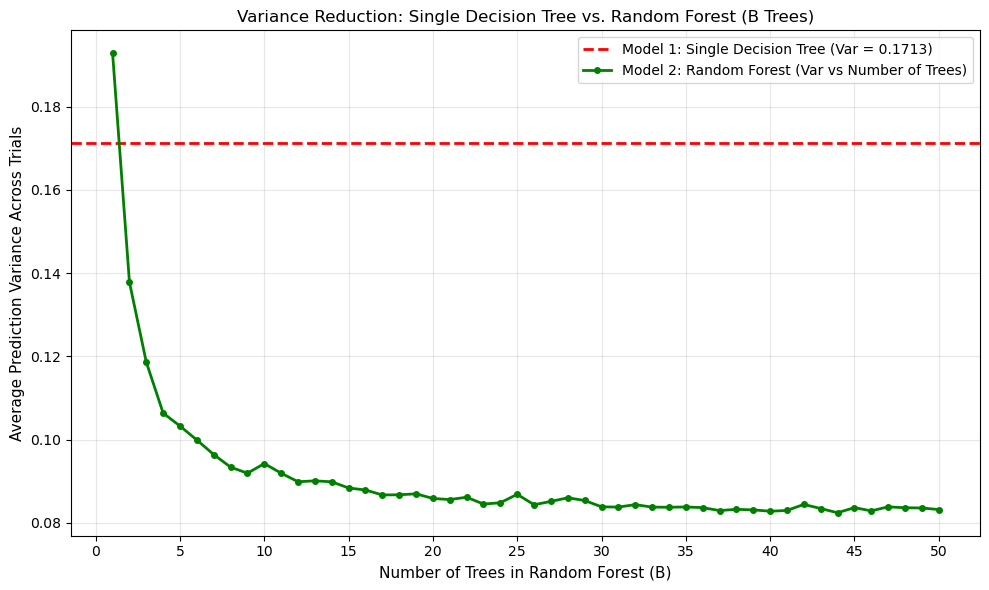

Model 1 (Single Decision Tree) Variance : 0.1713
Model 2 (RF with B=1 tree) Variance    : 0.1928
Model 2 (RF with B=10 trees) Variance   : 0.0942
Model 2 (RF with B=50 trees) Variance   : 0.0832


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Set random seed
np.random.seed(42)

# -----------------------------------------------------------------------------
# 1. Setup Ground Truth & Monte Carlo Parameters
# -----------------------------------------------------------------------------
X_test = np.linspace(0, 10, 300)[:, np.newaxis]
y_true = np.sin(X_test).ravel()

N_TRIALS = 100        # Number of independent dataset draws
N_SAMPLES = 40       # Sample size per draw
NOISE_STD = 0.4      # Noise level
tree_numbers = np.arange(1, 51)  # B = 1, 2, ..., 50

# Matrix arrays to collect predictions: shape (N_TRIALS, len(X_test))
dt_predictions = np.zeros((N_TRIALS, len(X_test)))
rf_predictions_by_b = np.zeros((len(tree_numbers), N_TRIALS, len(X_test)))

# -----------------------------------------------------------------------------
# 2. Run Simulation
# -----------------------------------------------------------------------------
# Define shared tree hyperparameters to ensure identical depth setup
TREE_PARAMS = dict(max_depth=None, min_samples_split=2, random_state=None)

for trial in range(N_TRIALS):
    # Draw new noisy training dataset from the population
    X_train = np.random.uniform(0, 10, N_SAMPLES)[:, np.newaxis]
    y_train = np.sin(X_train).ravel() + np.random.normal(0, NOISE_STD, N_SAMPLES)
    
    # --- Model 1: Single Decision Tree (Trained on 100% of data without bootstrap) ---
    dt = DecisionTreeRegressor(**TREE_PARAMS)
    dt.fit(X_train, y_train)
    dt_predictions[trial, :] = dt.predict(X_test)
    
    # --- Model 2: Random Forest with B trees ---
    for idx, B in enumerate(tree_numbers):
        rf = RandomForestRegressor(n_estimators=B, **TREE_PARAMS)
        rf.fit(X_train, y_train)
        rf_predictions_by_b[idx, trial, :] = rf.predict(X_test)

# -----------------------------------------------------------------------------
# 3. Calculate Variance across Trials
# -----------------------------------------------------------------------------
# Model 1 Variance (constant line across all B)
model1_variance = np.mean(np.var(dt_predictions, axis=0))

# Model 2 Variance for each B
model2_variances = []
for idx in range(len(tree_numbers)):
    # Var across N_TRIALS at each point along X_test, averaged over the domain
    var_B = np.mean(np.var(rf_predictions_by_b[idx, :, :], axis=0))
    model2_variances.append(var_B)

# -----------------------------------------------------------------------------
# 4. Plot Model 1 vs. Model 2 Variance Curve
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 6))

# Plot Model 1 baseline
plt.axhline(y=model1_variance, color='red', linestyle='--', linewidth=2, 
            label=f'Model 1: Single Decision Tree (Var = {model1_variance:.4f})')

# Plot Model 2 curve
plt.plot(tree_numbers, model2_variances, color='green', marker='o', markersize=4, linewidth=2,
         label='Model 2: Random Forest (Var vs Number of Trees)')

plt.title("Variance Reduction: Single Decision Tree vs. Random Forest (B Trees)", fontsize=12)
plt.xlabel("Number of Trees in Random Forest (B)", fontsize=11)
plt.ylabel("Average Prediction Variance Across Trials", fontsize=11)
plt.xticks(np.arange(0, 51, 5))
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary metrics
print(f"Model 1 (Single Decision Tree) Variance : {model1_variance:.4f}")
print(f"Model 2 (RF with B=1 tree) Variance    : {model2_variances[0]:.4f}")
print(f"Model 2 (RF with B=10 trees) Variance   : {model2_variances[9]:.4f}")
print(f"Model 2 (RF with B=50 trees) Variance   : {model2_variances[-1]:.4f}")

## 1.2. Classification

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import ipywidgets as widgets
from ipywidgets import interact

# -----------------------------------------------------------------------------
# Interactive Classification Variance Simulation with Instance Slider
# -----------------------------------------------------------------------------
def plot_classification_variance_interactive_instance(
    data_only=False,
    n_simulations=25,
    sim_instance=1,
    sample_size=50, 
    noise_level=0.38, 
    unpruned=True, 
    n_trees=100
):
    # Ensure active instance index remains valid if n_simulations slider shrinks
    active_idx = min(sim_instance - 1, n_simulations - 1)
    actual_instance_num = active_idx + 1

    # 2D Grid covering feature domain
    x_min, x_max = -2.0, 3.0
    y_min, y_max = -1.5, 2.0
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250),
                         np.linspace(y_min, y_max, 250))
    grid = np.c_[xx.ravel(), yy.ravel()]
    
    dt_probas = []
    rf_probas = []
    all_sim_data = []  # Store generated datasets across all simulations
    
    depth = None if unpruned else 6
    
    # 1. Run independent simulation draws
    for i in range(n_simulations):
        X_sim, y_sim = make_moons(n_samples=sample_size, noise=noise_level, random_state=i)
        all_sim_data.append((X_sim, y_sim))
        
        dt = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(X_sim, y_sim)
        rf = RandomForestClassifier(n_estimators=n_trees, max_depth=depth, random_state=42).fit(X_sim, y_sim)
        
        dt_probas.append(dt.predict_proba(grid)[:, 1])
        rf_probas.append(rf.predict_proba(grid)[:, 1])
        
    dt_probas = np.array(dt_probas)
    rf_probas = np.array(rf_probas)
    
    # Pointwise probability standard deviation across all simulations
    dt_std_grid = np.std(dt_probas, axis=0).reshape(xx.shape)
    rf_std_grid = np.std(rf_probas, axis=0).reshape(xx.shape)
    
    # High-contrast color palette
    color_class0 = '#00E5FF'  # Electric Cyan (Class 0)
    color_class1 = '#FF2A00'  # Electric Red-Orange (Class 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
    vmax = 0.45  # Fixed scale maximum for heatmap variance comparison
    
    # Helper to plot data points
    def draw_scatter_points(ax, show_all_sims=False):
        if show_all_sims:
            # Faded points across all simulation draws showing total data distribution cloud
            for X_s, y_s in all_sim_data:
                ax.scatter(X_s[y_s == 0, 0], X_s[y_s == 0, 1], c=color_class0, s=15, alpha=0.08)
                ax.scatter(X_s[y_s == 1, 0], X_s[y_s == 1, 1], c=color_class1, s=15, alpha=0.08)
        
        # Solid dots with white borders: Selected ACTIVE instance dataset
        X_active, y_active = all_sim_data[active_idx]
        ax.scatter(
            X_active[y_active == 0, 0], X_active[y_active == 0, 1],
            c=color_class0, edgecolors='white', linewidths=1.2, s=60, zorder=5, 
            label=f'Class 0 (Instance #{actual_instance_num})'
        )
        ax.scatter(
            X_active[y_active == 1, 0], X_active[y_active == 1, 1],
            c=color_class1, edgecolors='white', linewidths=1.2, s=60, zorder=5, 
            label=f'Class 1 (Instance #{actual_instance_num})'
        )

    # -------------------------------------------------------------------------
    # MODE 1: SHOW DATA DISTRIBUTION ONLY
    # -------------------------------------------------------------------------
    if data_only:
        for ax, title in zip(axes, ["Single Decision Tree Domain", "Random Forest Domain"]):
            ax.set_facecolor('#111111')
            draw_scatter_points(ax, show_all_sims=True)
            ax.set_title(
                f"{title}\nViewing Simulation Instance #{actual_instance_num} of {n_simulations}",
                fontsize=11, fontweight='bold'
            )

    # -------------------------------------------------------------------------
    # MODE 2: SHOW MODEL VARIANCE HEATMAPS + DATA OVERLAY
    # -------------------------------------------------------------------------
    else:
        # Decision Tree Panel
        im0 = axes[0].pcolormesh(xx, yy, dt_std_grid, cmap='inferno', vmin=0, vmax=vmax, shading='auto')
        draw_scatter_points(axes[0], show_all_sims=False)
        axes[0].set_title(
            f"Single Decision Trees ({'Unpruned' if unpruned else f'Depth={depth}'})\n"
            f"Avg Prob Std Dev: {np.mean(dt_std_grid):.3f} (High Spatial Chaos)",
            fontsize=11, fontweight='bold'
        )
        fig.colorbar(im0, ax=axes[0], label=r'Prediction Std Dev $\sigma_P(x_1, x_2)$')

        # Random Forest Panel
        im1 = axes[1].pcolormesh(xx, yy, rf_std_grid, cmap='inferno', vmin=0, vmax=vmax, shading='auto')
        draw_scatter_points(axes[1], show_all_sims=False)
        axes[1].set_title(
            f"Random Forest ({n_trees} Trees)\n"
            f"Avg Prob Std Dev: {np.mean(rf_std_grid):.3f} (Squeezed to Boundary)",
            fontsize=11, fontweight='bold'
        )
        fig.colorbar(im1, ax=axes[1], label=r'Prediction Std Dev $\sigma_P(x_1, x_2)$')

    # Formatting axes
    for ax in axes:
        ax.set_xlabel("Feature 1")
        ax.set_ylabel("Feature 2")
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.legend(loc='upper right', facecolor='#222222', labelcolor='white', framealpha=0.85)
        ax.grid(True, alpha=0.2)

    # Explanatory Caption Banner
    caption_text = (
        f"• Solid Dots (White Borders): Active Dataset Instance #{actual_instance_num} of {n_simulations} "
        f"(N={sample_size}, Cyan = Class 0, Red-Orange = Class 1).\n"
        f"• Background Heatmap: Fixed Prediction Variance computed across ALL {n_simulations} simulation runs."
    )
    
    fig.text(
        0.5, -0.02, caption_text,
        ha='center', va='top', fontsize=10, fontweight='medium',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#F0F4F8', edgecolor='#B0BEC5', alpha=0.95)
    )

    plt.tight_layout()
    plt.show()

# -----------------------------------------------------------------------------
# Widget Setup with "View Instance" Slider
# -----------------------------------------------------------------------------
interact(
    plot_classification_variance_interactive_instance,
    data_only=widgets.Checkbox(value=False, description='Show Data Only'),
    unpruned=widgets.Checkbox(value=True, description='Unpruned Trees (max_depth=None)'),
    n_simulations=widgets.IntSlider(min=10, max=50, step=5, value=25, description='Simulations:'),
    sim_instance=widgets.IntSlider(min=1, max=50, step=1, value=1, description='View Instance:'),
    sample_size=widgets.IntSlider(min=30, max=150, step=10, value=50, description='Sample Size:'),
    noise_level=widgets.FloatSlider(min=0.20, max=0.50, step=0.05, value=0.38, description='Data Noise:'),
    n_trees=widgets.IntSlider(min=10, max=200, step=10, value=100, description='Forest Trees:')
);

interactive(children=(Checkbox(value=False, description='Show Data Only'), IntSlider(value=25, description='Si…

# 2. Overfit

## 2.1. Regression

In [62]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# -----------------------------------------------------------------------------
# 1. Ground Truth & Synthetic Data Generator
# -----------------------------------------------------------------------------
X_true = np.linspace(0, 10, 500)[:, np.newaxis]
y_true = np.sin(X_true).ravel()

X_test = np.linspace(0, 10, 1000)[:, np.newaxis]
y_test = np.sin(X_test).ravel()

# Globally locked axes limits so the plot scale never shifts
X_LIM = (-0.2, 10.2)
Y_LIM = (-2.5, 2.5)


def generate_data(n_samples=40, noise_std=0.4):
    """Generate noisy training samples along sin(x)."""
    X = np.sort(np.random.uniform(0, 10, n_samples), axis=0)[:, np.newaxis]
    noise = np.random.normal(0, noise_std, size=X.shape[0])
    y = np.sin(X).ravel() + noise
    return X, y


# -----------------------------------------------------------------------------
# 2. State Container (Models & Data)
# -----------------------------------------------------------------------------
class ExperimentState:

    def __init__(self):
        self.X_train = None
        self.y_train = None
        self.resample()

    def resample(self):
        # 1. Resample data
        self.X_train, self.y_train = generate_data()

        # 2. Fit Decision Tree
        self.tree = DecisionTreeRegressor(random_state=42)
        self.tree.fit(self.X_train, self.y_train)
        self.y_pred_tree = self.tree.predict(X_test)
        self.mse_tree = np.mean((self.y_pred_tree - y_test) ** 2)

        # 3. Fit Random Forest
        self.rf = RandomForestRegressor(n_estimators=100, random_state=42)
        self.rf.fit(self.X_train, self.y_train)
        self.y_pred_rf = self.rf.predict(X_test)
        self.mse_rf = np.mean((self.y_pred_rf - y_test) ** 2)


state = ExperimentState()

# -----------------------------------------------------------------------------
# 3. Interactive Widgets
# -----------------------------------------------------------------------------
chk_true = widgets.Checkbox(value=True, description="True Signal", indent=False)
chk_data = widgets.Checkbox(value=True, description="Data Points", indent=False)
chk_models = widgets.Checkbox(value=True, description="Models", indent=False)

btn_resample = widgets.Button(
    description="Generate New Data", button_style="info", icon="refresh"
)

out = widgets.Output()

# -----------------------------------------------------------------------------
# 4. Rendering & External Shared Legend
# -----------------------------------------------------------------------------
def render_plot():
    with out:
        out.clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

        # Lock identical X and Y bounds across all interactions
        for ax in axes:
            ax.set_xlim(X_LIM)
            ax.set_ylim(Y_LIM)
            ax.grid(True, alpha=0.3)

        handles = []
        labels = []

        # 1. True Signal
        if chk_true.value:
            (line_true,) = axes[0].plot(
                X_true,
                y_true,
                color="black",
                linestyle="--",
                alpha=0.7,
                label="True Signal sin(x)",
            )
            axes[1].plot(
                X_true, y_true, color="black", linestyle="--", alpha=0.7
            )
            handles.append(line_true)
            labels.append("True Signal sin(x)")

        # 2. Data Points
        if chk_data.value:
            scatter_pts = axes[0].scatter(
                state.X_train,
                state.y_train,
                color="red",
                zorder=5,
                s=30,
                label="Noisy Train Data",
            )
            axes[1].scatter(
                state.X_train,
                state.y_train,
                color="red",
                zorder=5,
                s=30,
                label="Noisy Train Data",
            )
            handles.append(scatter_pts)
            labels.append("Noisy Train Data")

        # 3. Models
        if chk_models.value:
            (line_dt,) = axes[0].plot(
                X_test,
                state.y_pred_tree,
                color="blue",
                linewidth=2,
                label="Decision Tree Prediction",
            )
            (line_rf,) = axes[1].plot(
                X_test,
                state.y_pred_rf,
                color="green",
                linewidth=2,
                label="Random Forest Prediction",
            )
            handles.extend([line_dt, line_rf])
            labels.extend(
                ["Decision Tree Prediction", "Random Forest Prediction"]
            )

        # Subplot Titles & Metrics
        axes[0].set_title(
            f"Decision Tree (Overfitted)\nTest MSE vs True Signal:"
            f" {state.mse_tree:.4f}",
            fontsize=11,
        )
        axes[1].set_title(
            f"Random Forest (Averaged/Smoothed)\nTest MSE vs True Signal:"
            f" {state.mse_rf:.4f}",
            fontsize=11,
        )

        # Single Shared Legend outside the subplots
        if handles:
            fig.legend(
                handles,
                labels,
                loc="upper center",
                bbox_to_anchor=(0.5, 0.99),
                ncol=len(handles),
                frameon=True,
                fontsize=10,
            )

        # Padding at top to prevent legend-title overlap
        plt.tight_layout(rect=[0, 0, 1, 0.88])
        plt.show()


# -----------------------------------------------------------------------------
# 5. Widget Event Observers
# -----------------------------------------------------------------------------
def on_toggle_change(change):
    render_plot()


def on_resample_click(button):
    state.resample()
    render_plot()


chk_true.observe(on_toggle_change, names="value")
chk_data.observe(on_toggle_change, names="value")
chk_models.observe(on_toggle_change, names="value")
btn_resample.on_click(on_resample_click)

# -----------------------------------------------------------------------------
# 6. Display Controls & Canvas
# -----------------------------------------------------------------------------
controls = widgets.HBox(
    [chk_true, chk_data, chk_models, btn_resample],
    layout=widgets.Layout(
        gap="20px", align_items="center", margin="8px 0 14px 0"
    ),
)

display(controls, out)
render_plot()

Output()

In [64]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from matplotlib.lines import Line2D
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# -----------------------------------------------------------------------------
# 1. Ground Truth & Synthetic Classification Data
# -----------------------------------------------------------------------------
# True boundary: x2 = sin(x1)
x1_true = np.linspace(0, 10, 500)
x2_true = np.sin(x1_true)

# Dense 2D grid for evaluating decision boundaries and accuracy
grid_x1 = np.linspace(0, 10, 200)
grid_x2 = np.linspace(-2.5, 2.5, 200)
XX, YY = np.meshgrid(grid_x1, grid_x2)
X_test = np.c_[XX.ravel(), YY.ravel()]
y_test_true = (YY.ravel() > np.sin(XX.ravel())).astype(int)

# Globally locked axes limits so the plot scale never shifts
X_LIM = (-0.2, 10.2)
Y_LIM = (-2.5, 2.5)


def generate_data(n_samples=65, noise_flip_prob=0.12):
    """Generate 2D points separated by sin(x1) with random label noise."""
    X1 = np.random.uniform(0, 10, n_samples)
    X2 = np.random.uniform(-2.2, 2.2, n_samples)
    X = np.column_stack([X1, X2])

    # True Bayes class: 1 if above sin(x1), 0 otherwise
    y_clean = (X2 > np.sin(X1)).astype(int)

    # Inject label flip noise near the boundary
    flips = np.random.rand(n_samples) < noise_flip_prob
    y = np.where(flips, 1 - y_clean, y_clean)
    return X, y


# -----------------------------------------------------------------------------
# 2. State Container (Models & Data)
# -----------------------------------------------------------------------------
class ExperimentState:

    def __init__(self):
        self.X_train = None
        self.y_train = None
        self.resample()

    def resample(self):
        # 1. Resample training dataset
        self.X_train, self.y_train = generate_data()

        # 2. Fit Decision Tree Classifier
        self.dt = DecisionTreeClassifier(random_state=42)
        self.dt.fit(self.X_train, self.y_train)
        self.prob_dt = self.dt.predict_proba(X_test)[:, 1].reshape(XX.shape)
        self.acc_dt = np.mean(self.dt.predict(X_test) == y_test_true)

        # 3. Fit Random Forest Classifier
        self.rf = RandomForestClassifier(n_estimators=100, random_state=42)
        self.rf.fit(self.X_train, self.y_train)
        self.prob_rf = self.rf.predict_proba(X_test)[:, 1].reshape(XX.shape)
        self.acc_rf = np.mean(self.rf.predict(X_test) == y_test_true)


state = ExperimentState()

# -----------------------------------------------------------------------------
# 3. Interactive Widgets
# -----------------------------------------------------------------------------
chk_true = widgets.Checkbox(value=True, description="True Signal", indent=False)
chk_data = widgets.Checkbox(value=True, description="Data Points", indent=False)
chk_models = widgets.Checkbox(value=True, description="Models", indent=False)

btn_resample = widgets.Button(
    description="Generate New Data", button_style="info", icon="refresh"
)

out = widgets.Output()

# -----------------------------------------------------------------------------
# 4. Rendering & External Shared Legend
# -----------------------------------------------------------------------------
def render_plot():
    with out:
        out.clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

        # Lock identical X and Y bounds across all interactions
        for ax in axes:
            ax.set_xlim(X_LIM)
            ax.set_ylim(Y_LIM)
            ax.grid(True, alpha=0.3)

        legend_handles = []
        legend_labels = []

        # 1. True Signal (Decision Boundary)
        if chk_true.value:
            for ax in axes:
                ax.plot(
                    x1_true,
                    x2_true,
                    color="black",
                    linestyle="--",
                    linewidth=1.8,
                    alpha=0.7,
                )
            legend_handles.append(
                Line2D(
                    [0],
                    [0],
                    color="black",
                    linestyle="--",
                    linewidth=1.8,
                    alpha=0.7,
                )
            )
            legend_labels.append("True Boundary sin(x)")

        # 2. Data Points
        if chk_data.value:
            mask_0 = state.y_train == 0
            mask_1 = state.y_train == 1

            for ax in axes:
                ax.scatter(
                    state.X_train[mask_0, 0],
                    state.X_train[mask_0, 1],
                    color="#e74c3c",
                    edgecolor="k",
                    linewidth=0.5,
                    s=35,
                    zorder=5,
                )
                ax.scatter(
                    state.X_train[mask_1, 0],
                    state.X_train[mask_1, 1],
                    color="#3498db",
                    marker="s",
                    edgecolor="k",
                    linewidth=0.5,
                    s=35,
                    zorder=5,
                )

            legend_handles.extend([
                Line2D(
                    [0],
                    [0],
                    marker="o",
                    color="w",
                    markerfacecolor="#e74c3c",
                    markeredgecolor="k",
                    markersize=7,
                ),
                Line2D(
                    [0],
                    [0],
                    marker="s",
                    color="w",
                    markerfacecolor="#3498db",
                    markeredgecolor="k",
                    markersize=7,
                ),
            ])
            legend_labels.extend(["Class 0 Data", "Class 1 Data"])

        # 3. Models (Decision Boundaries & Shaded Regions)
        if chk_models.value:
            # Decision Tree boundary
            axes[0].contourf(
                XX,
                YY,
                state.prob_dt,
                levels=[-0.01, 0.5, 1.01],
                colors=["#ffcccc", "#cce5ff"],
                alpha=0.25,
            )
            axes[0].contour(
                XX,
                YY,
                state.prob_dt,
                levels=[0.5],
                colors=["blue"],
                linewidths=2.2,
            )

            # Random Forest boundary
            axes[1].contourf(
                XX,
                YY,
                state.prob_rf,
                levels=[-0.01, 0.5, 1.01],
                colors=["#ffcccc", "#cce5ff"],
                alpha=0.25,
            )
            axes[1].contour(
                XX,
                YY,
                state.prob_rf,
                levels=[0.5],
                colors=["green"],
                linewidths=2.2,
            )

            legend_handles.extend([
                Line2D([0], [0], color="blue", linewidth=2.2),
                Line2D([0], [0], color="green", linewidth=2.2),
            ])
            legend_labels.extend(
                ["Decision Tree Boundary", "Random Forest Boundary"]
            )

        # Subplot Titles & Metrics
        axes[0].set_title(
            f"Decision Tree (Overfitted)\nTest Accuracy vs True Boundary:"
            f" {state.acc_dt:.1%}",
            fontsize=11,
        )
        axes[1].set_title(
            f"Random Forest (Averaged/Smoothed)\nTest Accuracy vs True Boundary:"
            f" {state.acc_rf:.1%}",
            fontsize=11,
        )

        # Single Shared Legend outside the subplots
        if legend_handles:
            fig.legend(
                legend_handles,
                legend_labels,
                loc="upper center",
                bbox_to_anchor=(0.5, 0.99),
                ncol=len(legend_handles),
                frameon=True,
                fontsize=10,
            )

        # Top margin reservation to keep legend and titles decoupled
        plt.tight_layout(rect=[0, 0, 1, 0.88])
        plt.show()


# -----------------------------------------------------------------------------
# 5. Widget Event Observers
# -----------------------------------------------------------------------------
def on_toggle_change(change):
    render_plot()


def on_resample_click(button):
    state.resample()
    render_plot()


chk_true.observe(on_toggle_change, names="value")
chk_data.observe(on_toggle_change, names="value")
chk_models.observe(on_toggle_change, names="value")
btn_resample.on_click(on_resample_click)

# -----------------------------------------------------------------------------
# 6. Display Controls & Canvas
# -----------------------------------------------------------------------------
controls = widgets.HBox(
    [chk_true, chk_data, chk_models, btn_resample],
    layout=widgets.Layout(
        gap="20px", align_items="center", margin="8px 0 14px 0"
    ),
)

display(controls, out)
render_plot()

Output()

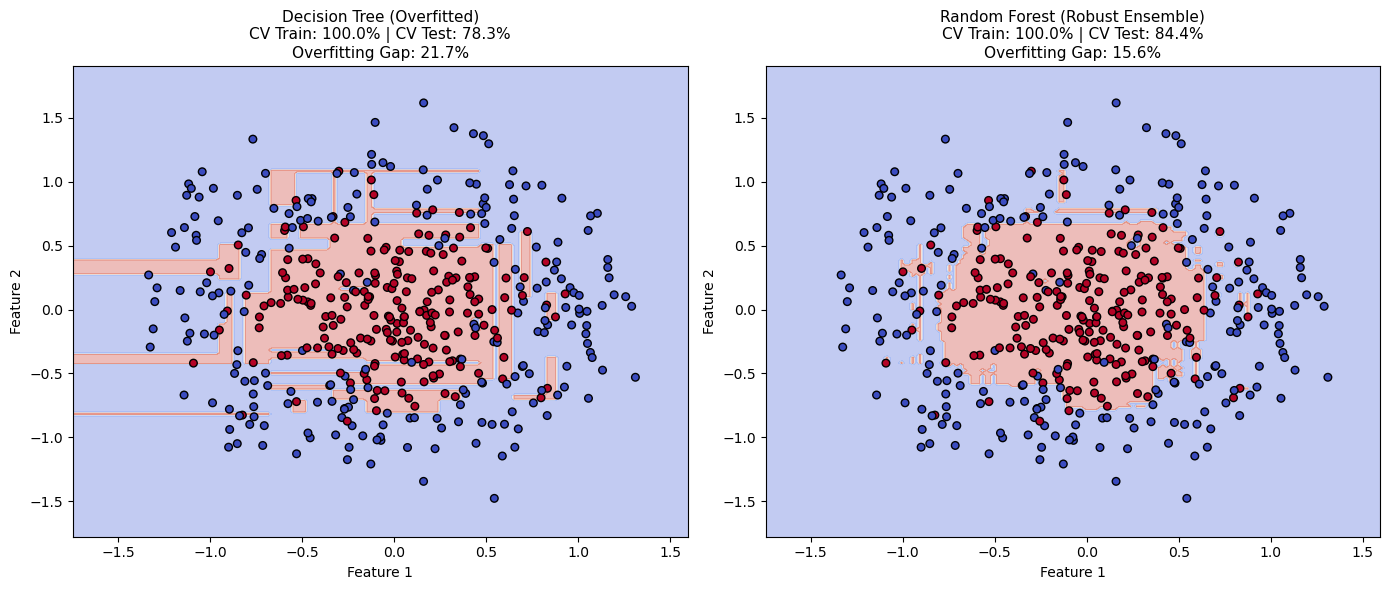

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, train_test_split

# -----------------------------------------------------------------------------
# 1. Generate Concentric Circles Data + Random Noise Injection
# -----------------------------------------------------------------------------
np.random.seed(42)

# Generate main circle dataset with noise
X, y = make_circles(n_samples=600, factor=0.4, noise=0.25, random_state=42)

# Add 30 purely random "corrupted" outlier points inside the boundary
X_outliers = np.random.uniform(low=-1.2, high=1.2, size=(30, 2))
y_outliers = np.random.choice([0, 1], size=30)  # Random labels

X = np.vstack([X, X_outliers])
y = np.hstack([y, y_outliers])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# -----------------------------------------------------------------------------
# 2. Train Models
# -----------------------------------------------------------------------------
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Calculate 5-Fold Cross-Validation Scores
cv_tree = cross_validate(tree, X, y, cv=5, return_train_score=True)
cv_rf = cross_validate(rf, X, y, cv=5, return_train_score=True)

tree_train_acc, tree_test_acc = cv_tree['train_score'].mean(), cv_tree['test_score'].mean()
rf_train_acc, rf_test_acc = cv_rf['train_score'].mean(), cv_rf['test_score'].mean()

# -----------------------------------------------------------------------------
# 3. Plot Decision Boundaries
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

def plot_boundary(clf, ax, title):
    x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
    y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=plt.cm.coolwarm)
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.coolwarm, edgecolors='k', s=30)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plot_boundary(
    tree, axes[0], 
    f"Decision Tree (Overfitted)\nCV Train: {tree_train_acc:.1%} | CV Test: {tree_test_acc:.1%}\nOverfitting Gap: {tree_train_acc - tree_test_acc:.1%}"
)

plot_boundary(
    rf, axes[1], 
    f"Random Forest (Robust Ensemble)\nCV Train: {rf_train_acc:.1%} | CV Test: {rf_test_acc:.1%}\nOverfitting Gap: {rf_train_acc - rf_test_acc:.1%}"
)

plt.tight_layout()
plt.show()

# 3. Robostness

## 3.1. Regression

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import ipywidgets as widgets
from ipywidgets import interact

# -----------------------------------------------------------------------------
# 1. Interactive Plotting Function
# -----------------------------------------------------------------------------
def plot_outlier_location_demo(outlier_x=5.0, outlier_y=5.0, n_trees=100):
    # Clean underlying signal
    X_clean = np.linspace(0, 10, 100)[:, np.newaxis]
    y_clean = np.sin(X_clean).ravel()
    
    # Inject 1 outlier at user-selected (outlier_x, outlier_y)
    X = np.vstack([X_clean, [[outlier_x]]])
    y = np.append(y_clean, outlier_y)
    
    # Test domain for smooth plotting
    X_test = np.linspace(0, 10, 500)[:, np.newaxis]
    
    # 1. Decision Tree (standard settings)
    dt = DecisionTreeRegressor(random_state=42, min_samples_leaf=2).fit(X, y)
    dt_pred = dt.predict(X_test)
    
    # 2. Random Forest (Median Criterion + Leaf Floor = Fully Immune)
    rf = RandomForestRegressor(
        n_estimators=n_trees,
        criterion='absolute_error',  # Uses median instead of mean
        min_samples_leaf=3,          # Requires at least 3 points per leaf
        random_state=42
    ).fit(X, y)
    rf_pred = rf.predict(X_test)
    
    # 3. Plotting
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    
    # --- Decision Tree ---
    axes[0].scatter(X_clean, y_clean, color='gray', alpha=0.5, label='Clean Data')
    axes[0].scatter([outlier_x], [outlier_y], color='red', s=150, zorder=5, 
                    label=f'Outlier ({outlier_x:.1f}, {outlier_y:.1f})')
    axes[0].plot(X_test, dt_pred, color='blue', linewidth=2.5, label='Decision Tree')
    axes[0].set_title(f"Single Decision Tree\n(Spike follows outlier to x={outlier_x:.1f}, y={outlier_y:.1f})", fontsize=11)
    axes[0].set_xlabel("X")
    axes[0].set_ylabel("Predicted Y")
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(-1.5, max(6.0, outlier_y + 0.5))
    
    # --- Random Forest ---
    axes[1].scatter(X_clean, y_clean, color='gray', alpha=0.5, label='Clean Data')
    axes[1].scatter([outlier_x], [outlier_y], color='red', s=150, zorder=5, 
                    label=f'Outlier ({outlier_x:.1f}, {outlier_y:.1f})')
    axes[1].plot(X_test, rf_pred, color='green', linewidth=3.5, label='Random Forest')
    axes[1].set_title("Random Forest (Median Criterion)\n(Curve stays perfect; ignores outlier entirely)", fontsize=11)
    axes[1].set_xlabel("X")
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# -----------------------------------------------------------------------------
# 2. Interactive Widget Sliders
# -----------------------------------------------------------------------------
interact(
    plot_outlier_location_demo,
    outlier_x=widgets.FloatSlider(min=1.0, max=9.0, step=0.5, value=5.0, description='Outlier X:'),
    outlier_y=widgets.FloatSlider(min=-1.0, max=8.0, step=0.5, value=5.0, description='Outlier Y:'),
    n_trees=widgets.IntSlider(min=10, max=200, step=1, value=100, description='Forest Trees:')
);

interactive(children=(FloatSlider(value=5.0, description='Outlier X:', max=9.0, min=1.0, step=0.5), FloatSlide…

## 3.2. Classification

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import ipywidgets as widgets
from ipywidgets import interact

# -----------------------------------------------------------------------------
# 1. Interactive Classification Plotting Function
# -----------------------------------------------------------------------------
def plot_classification_outlier_demo(outlier_x=-1.5, outlier_y=0.0, outlier_class=1, n_trees=100):
    np.random.seed(42)
    
    # Generate 2 clean, separated clusters (Class 0 at X=-1.2, Class 1 at X=+1.2)
    X_clean, y_clean = make_blobs(
        n_samples=120, 
        centers=[[-1.2, 0.0], [1.2, 0.0]], 
        cluster_std=0.45, 
        random_state=42
    )
    
    # Inject user-controlled outlier point
    X = np.vstack([X_clean, [[outlier_x, outlier_y]]])
    y = np.append(y_clean, outlier_class)
    
    # Dense 2D grid for decision boundaries
    x_min, x_max = -3.0, 3.0
    y_min, y_max = -2.5, 2.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    
    # 1. Single Decision Tree (standard settings)
    dt = DecisionTreeClassifier(random_state=42, min_samples_leaf=1).fit(X, y)
    dt_pred = dt.predict(grid).reshape(xx.shape)
    
    # 2. Random Forest (Robust classification settings)
    rf = RandomForestClassifier(
        n_estimators=n_trees,
        min_samples_leaf=1,  # Prevents 1-point pure leaves
        random_state=42
    ).fit(X, y)
    rf_pred = rf.predict(grid).reshape(xx.shape)
    
    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    
    def draw_boundary(ax, pred, title):
        # Draw background class decision regions
        ax.contourf(xx, yy, pred, alpha=0.3, cmap=plt.cm.coolwarm)
        
        # Draw clean cluster points
        ax.scatter(X_clean[y_clean==0, 0], X_clean[y_clean==0, 1], 
                   c='red', edgecolors='k', s=35, label='Class 0 (Red)')
        ax.scatter(X_clean[y_clean==1, 0], X_clean[y_clean==1, 1], 
                   c='blue', edgecolors='k', s=35, label='Class 1 (Blue)')
        
        # Highlight custom outlier point
        outlier_color = 'blue' if outlier_class == 1 else 'red'
        ax.scatter([outlier_x], [outlier_y], c=outlier_color, edgecolors='yellow', 
                   linewidths=2.5, s=220, marker='*', 
                   label=f'Injected Outlier (Class {outlier_class})', zorder=5)
        
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Feature 1")
        ax.set_ylabel("Feature 2")
        ax.legend(loc='lower right')
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.grid(True, alpha=0.2)

    draw_boundary(axes[0], dt_pred, "Single Decision Tree\n(Carves out an artificial 'island' around the star)")
    draw_boundary(axes[1], rf_pred, f"Random Forest ({n_trees} Trees, min_samples_leaf=3)\n(Decision boundary stays clean; ignores outlier)")
    
    plt.tight_layout()
    plt.show()

# -----------------------------------------------------------------------------
# 2. Interactive Widget Sliders
# -----------------------------------------------------------------------------
interact(
    plot_classification_outlier_demo,
    outlier_x=widgets.FloatSlider(min=-2.5, max=2.5, step=0.2, value=-1.5, description='Outlier X:'),
    outlier_y=widgets.FloatSlider(min=-2.0, max=2.0, step=0.2, value=0.0, description='Outlier Y:'),
    outlier_class=widgets.Dropdown(
        options=[('Class 1 (Blue Star in Red Territory)', 1), 
                 ('Class 0 (Red Star in Blue Territory)', 0)], 
        value=1, 
        description='Outlier Class:'
    ),
    n_trees=widgets.IntSlider(min=10, max=200, step=10, value=100, description='Trees:')
);

interactive(children=(FloatSlider(value=-1.5, description='Outlier X:', max=2.5, min=-2.5, step=0.2), FloatSli…